<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


<h1>Extracting and Visualizing Stock Data</h1>


## Introduction
 The objective of this project is to collect stock market and revenue data for selected companies and visualize trends using Python.

<h2>Table of Contents</h2>
<div class="alert alert-block alert-info" style="margin-top: 20px">
    <ul>
        <li>Define a Function that Makes a Graph</li>
        <li> Use yfinance to Extract Stock Data</li>
        <li> Use Webscraping to Extract Tesla Revenue Data</li>
        <li> Use yfinance to Extract Stock Data</li>
        <li> Use Webscraping to Extract GME Revenue Data</li>
        <li> Plot Tesla Stock Graph</li>
        <li> Plot GameStop Stock Graph</li>
    </ul>

</div>

<hr>


<h3>Installing the related Libraries</h3>

In [2]:
!pip install yfinance
!pip install bs4
!pip install nbformat
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


**Import libraries**

In [4]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup

**Ignore warnings using the warnings module. You can use the filterwarnings function to filter or ignore specific warning messages or categories.**


In [6]:
import warnings
# Ignore all warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Define Graphing Function


In this section, I define the function `make_graph`. **It takes a dataframe with stock data (dataframe must contain Date and Close columns), a dataframe with revenue data (dataframe must contain Date and Revenue columns), and the name of the stock.**


In [41]:


import matplotlib.pyplot as plt

def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']


    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Stock price
    axes[0].plot(pd.to_datetime(stock_data.Date), stock_data.Close.astype("float"), label="Share Price", color="blue")
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")

    # Revenue
    axes[1].plot(pd.to_datetime(revenue_data.Date), revenue_data.Revenue.astype("float"), label="Revenue", color="green")
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")

    plt.tight_layout()
    plt.show()

##  Use yfinance to Extract Stock Data


Using the `Ticker` function enter the ticker symbol of the stock we want to extract data on to create a ticker object. The stock is Tesla and its ticker symbol is `TSLA`.


In [42]:
Tesla=yf.Ticker("TSLA")

Using the ticker object and the function `history` extract stock information and save it in a dataframe named `tesla_data`. Set the `period` parameter to ` "max" ` so we get information for the maximum amount of time.


In [43]:
tesla_data=Tesla.history(period="max")


**Reset the index** using the `reset_index(inplace=True)` function on the tesla_data DataFrame and display the first five rows of the `tesla_data` dataframe using the `head` function.


In [44]:
tesla_data.reset_index(inplace=True)
tesla_data.head(5)


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


In [9]:
tesla_data.tail(5)

,index,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
4027,4027,2026-07-06 00:00:00-04:00,397.500000,420.000000,390.500000,419.769989,54727900,0.0,0.0
4028,4028,2026-07-07 00:00:00-04:00,416.959991,419.559998,401.880005,402.899994,38149900,0.0,0.0
4029,4029,2026-07-08 00:00:00-04:00,399.380005,399.630005,390.510010,394.059998,33844900,0.0,0.0
4030,4030,2026-07-09 00:00:00-04:00,393.989990,407.859985,390.859985,406.549988,37835000,0.0,0.0
4031,4031,2026-07-10 00:00:00-04:00,410.489990,413.160004,402.809998,407.760010,33342700,0.0,0.0


## Use Webscraping to Extract Tesla Revenue Data


Use the `requests` library to download the webpage https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm Save the text of the response as a variable named `html_data`.


In [45]:
import requests
url="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"
html_data=requests.get(url).text

Parse the html data using `beautiful_soup` using parser i.e `html5lib` or `html.parser`.


In [46]:
from bs4 import BeautifulSoup
soup=BeautifulSoup(html_data,'html.parser')
import pandas as pd
tesla_revenue=pd.DataFrame(columns=["Date","Revenue"])

Using `BeautifulSoup` or the `read_html` function extract the table with `Tesla Revenue` and store it into a dataframe named `tesla_revenue`. The dataframe should have columns `Date` and `Revenue`.



* Create an Empty DataFrame
* Find the Relevant Table
* Check for the Tesla Quarterly Revenue Table
* Iterate Through Rows in the Table Body
* Extract Data from Columns
* Append Data to the DataFrame

In [47]:
for row in soup.find_all("tbody")[1].find_all("tr"):
    col=row.find_all('td')
    date=col[0].text
    revenue=col[1].text
    tesla_revenue=pd.concat([tesla_revenue,pd.DataFrame({"Date":[date],"Revenue":[revenue]})],ignore_index=True)
tesla_revenue.tail()

,Date,Revenue
49,2010-06-30,$28
50,2010-03-31,$21
51,2009-12-31,
52,2009-09-30,$46
53,2009-06-30,$27


**Execute the following line to remove the comma and dollar sign from the `Revenue` column.**


In [48]:
tesla_revenue["Revenue"] = tesla_revenue['Revenue'].str.replace(',|\$',"",regex=True)

**Execute the following lines to remove an null or empty strings in the Revenue column.**


In [49]:
tesla_revenue.dropna(inplace=True)

tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]

**Display the last 5 row of the `tesla_revenue` dataframe using the `tail` function.** 


In [50]:

tesla_revenue.tail()

,Date,Revenue
48,2010-09-30,31
49,2010-06-30,28
50,2010-03-31,21
52,2009-09-30,46
53,2009-06-30,27


**Display the first 5 row of the `tesla_revenue` dataframe using the `Head` function.** 

In [51]:
tesla_revenue.head()

,Date,Revenue
0,2022-09-30,21454
1,2022-06-30,16934
2,2022-03-31,18756
3,2021-12-31,17719
4,2021-09-30,13757


## Use yfinance to Extract Stock Data


**Using the `Ticker` function enter the ticker symbol of the stock we want to extract data on to create a ticker object. The stock is GameStop and its ticker symbol is `GME`.**

In [52]:
import yfinance as yf
GameStop=yf.Ticker("GME")

**Using the ticker object and the function `history` extract stock information and save it in a dataframe named `gme_data`. Set the `period` parameter to ` "max" ` so we get information for the maximum amount of time.**


In [53]:
gme_data=GameStop.history(period="max")

**Reset the index** using the `reset_index(inplace=True)` function on the gme_data DataFrame and display the first five rows of the `gme_data` dataframe using the `head` function. Take a screenshot of the results and code from the beginning of Question 3 to the results below.


In [54]:
gme_data.reset_index(inplace=True)
gme_data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620129,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658002,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615920,1.662210,1.603296,1.662210,6892800,0.0,0.0


##  Use Webscraping to Extract GME Revenue Data


**Use the `requests` library to download the webpage https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html. Save the text of the response as a variable named `html_data_2`**


In [55]:
import requests
url="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"
html_data_2=requests.get(url).text

**Parse the html data using `beautiful_soup` using parser i.e `html5lib` or `html.parser`.**


In [56]:
from bs4 import BeautifulSoup
soup=BeautifulSoup(html_data_2,'html.parser')

Using `BeautifulSoup` or the `read_html` function extract the table with `GameStop Revenue` and store it into a dataframe named `gme_revenue`. The dataframe should have columns `Date` and `Revenue`. Make sure the comma and dollar sign is removed from the `Revenue` column.


In [57]:
import pandas as pd
gme_revenue=pd.DataFrame(columns=["Date","Revenue"])
for row in soup.find_all("tbody")[1].find_all('tr'):
    col=row.find_all('td')
    date=col[0].text
    revenue=col[1].text
    gme_revenue=pd.concat([gme_revenue,pd.DataFrame({"Date":[date],"Revenue":[revenue]})],ignore_index=True)
    gme_revenue.head()

**Remove the comma and dollar sign, an null or empty strings from the Revenue column.**


In [58]:
gme_revenue["Revenue"] = gme_revenue['Revenue'].str.replace(',|\$',"",regex=True)
gme_revenue.dropna(inplace=True)

gme_revenue = gme_revenue[gme_revenue['Revenue'] != ""]

**Display the last five rows of the `gme_revenue` dataframe using the `tail` function.**


In [59]:

gme_revenue.tail()

,Date,Revenue
57,2006-01-31,1667
58,2005-10-31,534
59,2005-07-31,416
60,2005-04-30,475
61,2005-01-31,709


**Display the first five rows of the `gme_revenue` dataframe using the `Head` function.**


In [60]:

gme_revenue.head()

,Date,Revenue
0,2020-04-30,1021
1,2020-01-31,2194
2,2019-10-31,1439
3,2019-07-31,1286
4,2019-04-30,1548


##  Plot Tesla Stock Graph


Use the `make_graph` function to graph the Tesla Stock Data, also provide a title for the graph. Note the graph will only show data upto June 2021.


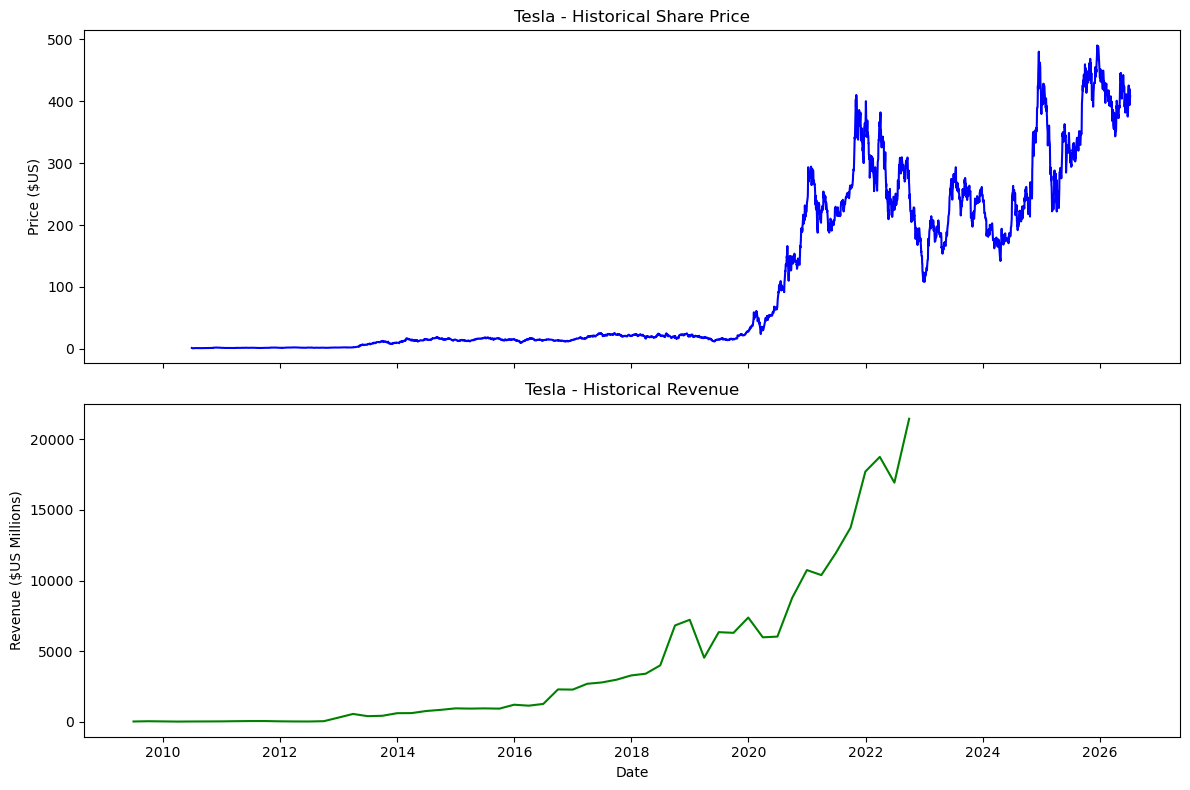

In [61]:
make_graph(tesla_data, tesla_revenue, 'Tesla')

##  Plot GameStop Stock Graph


Use the `make_graph` function to graph the GameStop Stock Data, also provide a title for the graph. The structure to call the `make_graph` function is `make_graph(gme_data, gme_revenue, 'GameStop')`. Note the graph will only show data upto June 2021.


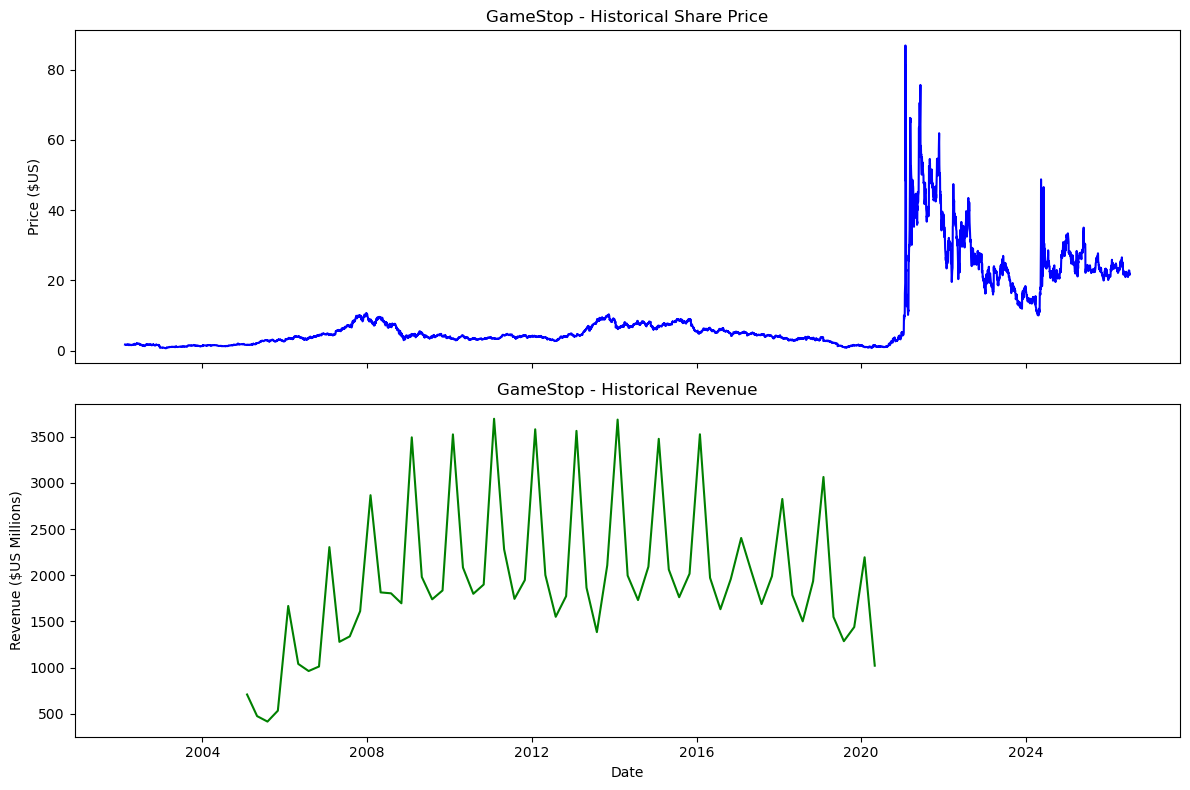

In [36]:
make_graph(gme_data, gme_revenue, 'GameStop')

<h2> Author: ACHALA JAIN </h2> 

